In [1]:
import os
import joblib
import json

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import f1_score, multilabel_confusion_matrix, \
    classification_report, accuracy_score

import numpy as np
import matplotlib.pyplot as plt

import torch
import tensorkrowch as tk
from tensorkrowch.utils import random_unitary

In [2]:
# TODO: instead of averaging models of all types, we should only average models
# trained with the same set of hyperparameters

# TODO: since training is a random process, we can also train several models
# using the same hyperparameters and partition of the dataset. Then, when
# averaging, we should average over models with the same hyperparameters but
# different dataset partition

# TODO: Maybe we should not average models as a method to improve privacy

# Create datasets

In [2]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

In [3]:
# Create whole models dataset
model_name = 'llr6' # 'llr6' or 'nn2'
scaler_type = 'standard' # 'standard' or 'minimax'
bond_dim = 2

all_labels = []
all_cores = []
all_bal_accs = []
all_auc_scores = []

tt_datasets_dir = os.path.join(cwd, 'tt_datasets', model_name, scaler_type, 'vanilla')
os.makedirs(tt_datasets_dir, exist_ok=True)

tt_models_dir = os.path.join(cwd, 'tt_models', model_name, scaler_type, 'vanilla')
for comb in os.listdir(tt_models_dir):
    aux_labels = [int(n) - 1 for n in comb.split('_')]
    one_hot_label = torch.zeros(len(datasets))
    one_hot_label[aux_labels] = 1
    
    comb_dir = os.path.join(tt_models_dir, comb)
    for C in [0.1, 1.0, 10.0]:
        for l1 in [0.0, 0.5, 1.0]:
            for i in range(100):
                cores_file = f'{C}_{l1}_{i}_cores.pkl'
                bal_accs_file = f'{C}_{l1}_{i}_bal_accs.json'
                auc_scores_file = f'{C}_{l1}_{i}_auc_scores.json'
                
                # cores
                cores_dir = os.path.join(comb_dir, cores_file)
                cores = torch.load(cores_dir, weights_only=True)
                
                # Make all cores equal size
                tt_model = tk.models.MPSLayer(tensors=cores)
                for j in range(len(tt_model.mats_env) - 1):
                    tt_model.mats_env[j]['right'].change_size(size=bond_dim)
                
                # Randomize gauge
                for i, node in enumerate(tt_model.mats_env):
                    U = random_unitary(node.size('right'))
                    if i < (len(tt_model.mats_env) - 1):
                        node.tensor = torch.einsum('lir,rk->lik',
                                                   node.tensor, U)
                    if i > 0:
                        node.tensor = torch.einsum('kl,lir->kir',
                                                   prev_U, node.tensor)
                    prev_U = U.clone().H
                
                cores = tt_model.tensors
                
                cores = [c.flatten() for c in cores]
                cores = torch.cat(cores, dim=0)
                    
                all_labels.append(one_hot_label.clone())
                all_cores.append(cores.clone())
                
                # bal accs
                bal_accs_dir = os.path.join(comb_dir, bal_accs_file)
                with open(bal_accs_dir, 'r') as f:
                    bal_accs_dict = json.load(f)
                
                bal_accs_vector = torch.zeros(len(datasets) + 1)
                for dat_id in datasets_ids:
                    bal_accs_vector[dat_id - 1] = bal_accs_dict[str(dat_id)]
                bal_accs_vector[-1] = bal_accs_dict['all']
                
                all_bal_accs.append(bal_accs_vector)
                
                # auc scores
                auc_scores_dir = os.path.join(comb_dir, auc_scores_file)
                with open(auc_scores_dir, 'r') as f:
                    auc_scores_dict = json.load(f)
                
                auc_scores_vector = torch.zeros(len(datasets) + 1)
                for dat_id in datasets_ids:
                    auc_scores_vector[dat_id - 1] = auc_scores_dict[str(dat_id)]
                auc_scores_vector[-1] = auc_scores_dict['all']
                
                all_auc_scores.append(auc_scores_vector)

all_labels = torch.stack(all_labels, dim=0).int()
all_cores = torch.stack(all_cores, dim=0)
all_bal_accs = torch.stack(all_bal_accs, dim=0)
all_auc_scores = torch.stack(all_auc_scores, dim=0)

# torch.save((all_labels, all_cores, all_bal_accs, all_auc_scores),
#            os.path.join(tt_datasets_dir, 'params_multilabel.pt'))

In [5]:
cond = (all_labels == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)

In [6]:
all_labels[cond]

tensor([[1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        ...,
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0]], dtype=torch.int32)

In [7]:
all_cores[cond][200:300, :][0]

tensor([-8.7251e-01,  4.8860e-01,  4.8860e-01,  8.7251e-01, -2.3640e-02,
         1.0903e-01,  7.5867e-02,  5.9882e-02,  1.7578e-02, -5.7422e-02,
        -4.1773e-02, -3.3099e-02,  1.2390e+00, -1.3551e-01,  3.7500e-01,
         1.6093e-01, -9.3958e-02,  7.0627e-01, -4.4975e-01, -1.7898e-01,
         2.6090e-01,  8.0638e-02,  4.3435e-03, -1.4420e-02, -1.3703e+00,
         2.1984e+00, -8.4852e-03,  3.0218e-02, -6.1782e-01,  6.7378e-01,
        -2.0124e-03, -1.7104e-03, -9.2595e-01, -4.2348e-01, -6.1337e-04,
        -5.4571e-04,  7.8395e-01, -3.4800e-01, -2.9156e-01, -1.3834e-01,
         2.9731e-01,  9.8053e-01,  3.1930e-01,  1.4542e-01, -5.4748e-01,
        -7.4706e-01,  2.5674e-01,  1.2406e-01, -7.2633e-01,  6.4992e-01,
        -4.6536e-01, -2.3591e-01, -9.9104e-01,  2.0162e-01, -2.1670e-01,
        -6.2098e-02, -2.1287e-01, -9.8095e-01,  5.0773e-01,  1.3224e-01,
         3.4595e-01, -1.1172e+00, -2.4447e-03,  4.7565e-02, -9.3795e-01,
        -3.9942e-01,  1.4164e-02, -1.6752e-01, -9.9

In [8]:
# Evaluate on Chowell_test
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 1]
        print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7475, std: 0.0056
C=0.1 , l1=0.5, mean: 0.7492, std: 0.0055
C=0.1 , l1=1.0, mean: 0.7477, std: 0.0169
C=1.0 , l1=0.0, mean: 0.7474, std: 0.0056
C=1.0 , l1=0.5, mean: 0.7476, std: 0.0055
C=1.0 , l1=1.0, mean: 0.7477, std: 0.0054
C=10.0, l1=0.0, mean: 0.7475, std: 0.0055
C=10.0, l1=0.5, mean: 0.7476, std: 0.0052
C=10.0, l1=1.0, mean: 0.7473, std: 0.0064


In [9]:
# Evaluate on Chowell_train
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 0]
        print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7403, std: 0.0021
C=0.1 , l1=0.5, mean: 0.7401, std: 0.0019
C=0.1 , l1=1.0, mean: 0.7349, std: 0.0147
C=1.0 , l1=0.0, mean: 0.7398, std: 0.0022
C=1.0 , l1=0.5, mean: 0.7395, std: 0.0022
C=1.0 , l1=1.0, mean: 0.7398, std: 0.0022
C=10.0, l1=0.0, mean: 0.7395, std: 0.0019
C=10.0, l1=0.5, mean: 0.7398, std: 0.0020
C=10.0, l1=1.0, mean: 0.7396, std: 0.0023


# LLR6

## Load and filter datasets

In [3]:
model_name = 'llr6' # 'llr6' or 'nn2'
scaler_type = 'standard' # 'standard' or 'minimax'
dataset_dir = os.path.join(cwd, 'tt_datasets', model_name, scaler_type, 'vanilla',
                           'params_multilabel.pt')

all_labels, all_cores, all_bal_accs, all_auc_scores = \
    torch.load(dataset_dir, weights_only=True)

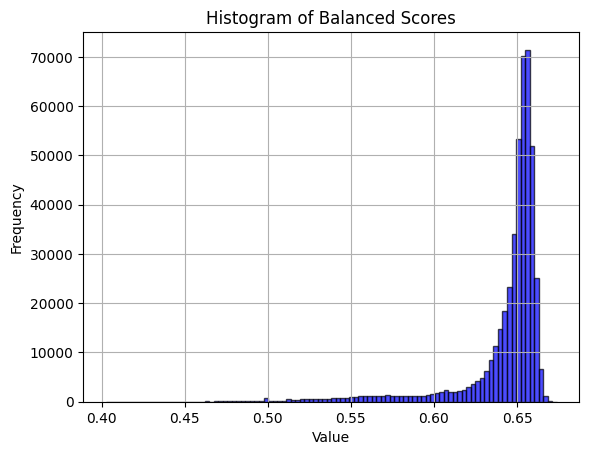

In [11]:
# Plot histogram scores
plt.hist(all_bal_accs[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

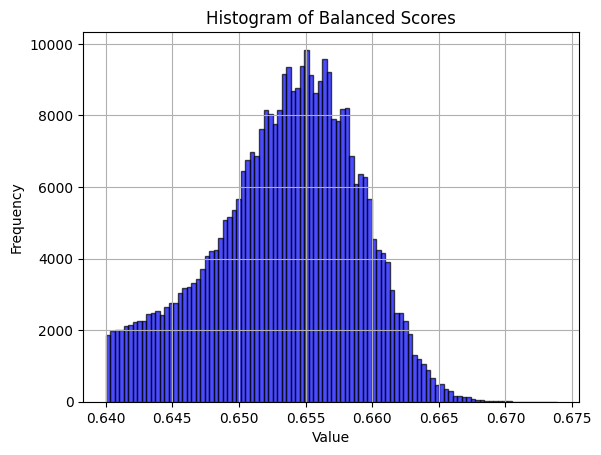

In [12]:
# Plot histogram scores
# idx = (all_bal_accs >= 0.55).all(dim=1)
idx = (all_bal_accs[:, -1] >= 0.64)
filtered_scores = all_bal_accs[idx]
plt.hist(filtered_scores[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

In [4]:
lower_bound = 0.64

# idx = (all_bal_accs >= lower_bound).all(dim=1)
idx = (all_bal_accs[:, -1] >= lower_bound)

all_labels = all_labels[idx]
all_cores = all_cores[idx]
all_bal_accs = all_bal_accs[idx]
all_auc_scores = all_auc_scores[idx]

## Black-box attack

In [ ]:
# Black-box attack
X, y = all_bal_accs, all_labels

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

# Define and train the MLP model
# mlp_bb = MLPClassifier(hidden_layer_sizes=(256, 128, 64, 32),
#                        activation="relu",
#                        solver="adam",
#                        max_iter=1000)
mlp_bb = MLPClassifier(hidden_layer_sizes=(128, 32),
                       activation="relu",
                       solver="adam",
                       max_iter=100)
mlp_bb.fit(X_train, y_train)

# Save model
attack_model_dir = os.path.join(cwd, 'attack_tt_models', model_name,
                                scaler_type, 'vanilla')
os.makedirs(attack_model_dir, exist_ok=True)

# joblib.dump(mlp_bb, os.path.join(attack_model_dir,
#                                  'mlp_attacker_multilabel_bb.pkl'))

/export/anaconda3/envs/loris/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


['/mathqi/joserapa/tns4loris/attacks/attack_tt_models/llr6/standard/vanilla/mlp_attacker_multilabel_bb.pkl']

In [8]:
attack_model_dir = os.path.join(cwd, 'attack_tt_models', model_name,
                                scaler_type, 'vanilla')
mlp_bb = joblib.load(os.path.join(attack_model_dir,
                                  'mlp_attacker_multilabel_bb.pkl'))

In [9]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

F1-score: 0.7098943543359535

Confusion Matrix for Class 0 - Chowell_train:
[[0.62005247 0.37994753]
 [0.00745553 0.99254447]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.87459595 0.12540405]
 [0.20511181 0.79488819]]

Confusion Matrix for Class 2 - MSK1:
[[0.86864626 0.13135374]
 [0.3575547  0.6424453 ]]

Confusion Matrix for Class 3 - MSK2:
[[0.93008659 0.06991341]
 [0.44115014 0.55884986]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.78343205 0.21656795]
 [0.5015441  0.4984559 ]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.66263162 0.33736838]
 [0.5227254  0.4772746 ]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.31990026 0.68009974]
 [0.13626105 0.86373895]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.87068049 0.12931951]
 [0.39063038 0.60936962]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.88084282 0.11915718]
 [0.56788449 0.43211551]]


              precision    recall  f1-score   support

           0       0.82      0.99      0.90     45872

## Black-box attack (AUC scores)

In [12]:
# Black-box attack
X, y = all_auc_scores, all_labels

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

# Define and train the MLP model
# mlp_bb = MLPClassifier(hidden_layer_sizes=(256, 128, 64, 32),
#                        activation="relu",
#                        solver="adam",
#                        max_iter=1000)
mlp_bb = MLPClassifier(hidden_layer_sizes=(128, 32),
                       activation="relu",
                       solver="adam",
                       max_iter=100)
mlp_bb.fit(X_train, y_train)

# Save model
attack_model_dir = os.path.join(cwd, 'attack_tt_models', model_name,
                                scaler_type, 'vanilla')
os.makedirs(attack_model_dir, exist_ok=True)

# joblib.dump(mlp_bb, os.path.join(attack_model_dir,
#                                  'mlp_attacker_multilabel_bb_auc.pkl'))

/export/anaconda3/envs/loris/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


['/mathqi/joserapa/tns4loris/attacks/attack_tt_models/llr6/standard/vanilla/mlp_attacker_multilabel_bb_auc.pkl']

In [13]:
attack_model_dir = os.path.join(cwd, 'attack_tt_models', model_name,
                                scaler_type, 'vanilla')
mlp_bb = joblib.load(os.path.join(attack_model_dir,
                                  'mlp_attacker_multilabel_bb_auc.pkl'))

In [14]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

F1-score: 0.7653414687913819

Confusion Matrix for Class 0 - Chowell_train:
[[8.98163418e-01 1.01836582e-01]
 [2.17997907e-05 9.99978200e-01]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.99092837 0.00907163]
 [0.09230031 0.90769969]]

Confusion Matrix for Class 2 - MSK1:
[[0.93168875 0.06831125]
 [0.24966639 0.75033361]]

Confusion Matrix for Class 3 - MSK2:
[[0.97850758 0.02149242]
 [0.76039604 0.23960396]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.65943661 0.34056339]
 [0.16457599 0.83542401]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.79979548 0.20020452]
 [0.58816575 0.41183425]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.78325547 0.21674453]
 [0.55061997 0.44938003]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.66819866 0.33180134]
 [0.09536554 0.90463446]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.84201179 0.15798821]
 [0.22649826 0.77350174]]


              precision    recall  f1-score   support

           0       0.94      1.00    

## White-box attack ensemble

In [ ]:
# White-box attack
X, y = all_cores.detach(), all_labels

attack_model_dir = os.path.join(cwd, 'attack_tt_models', model_name,
                                scaler_type, 'vanilla')
os.makedirs(attack_model_dir, exist_ok=True)

# First: Train/Test Split (held-out test set)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Save held-out test set (optional)
# joblib.dump((X_test, y_test), os.path.join(attack_model_dir,
#                                            'heldout_test_set.pkl'))

# K-Fold CV on training set
n_splits = 5
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)

for fold, (train_index, val_index) in enumerate(kfold.split(X_train_full,
                                                            y_train_full)):
    print(f"Training fold {fold+1}/{n_splits}...")

    X_train, X_val = X_train_full[train_index], X_train_full[val_index]
    y_train, y_val = y_train_full[train_index], y_train_full[val_index]

    # Define and train the model
    # mlp_wb = MLPClassifier(hidden_layer_sizes=(256, 128, 64, 32),
    #                        activation="relu",
    #                        solver="adam",
    #                        max_iter=500)
    mlp_wb = MLPClassifier(hidden_layer_sizes=(128, 32),
                           activation="relu",
                           solver="adam",
                           max_iter=100)
    mlp_wb.fit(X_train, y_train)

    # Save model for this fold
    # joblib.dump(mlp_wb,
    #             os.path.join(attack_model_dir,
    #                          f'mlp_attacker_multilabel_wb_fold_{fold+1}.pkl'))

Training fold 1/5...


/export/anaconda3/envs/loris/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Training fold 2/5...


/export/anaconda3/envs/loris/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Training fold 3/5...


In [10]:
# Save held-out test set (optional)
attack_model_dir = os.path.join(cwd, 'attack_tt_models', model_name,
                                scaler_type, 'vanilla')
X_test, y_test = joblib.load(os.path.join(attack_model_dir,
                                          'heldout_test_set.pkl'))

# Load models
n_splits = 5
loaded_models = []

# Load each model
for fold in range(1, n_splits + 1):
    model_path = os.path.join(attack_model_dir,
                              f'mlp_attacker_multilabel_wb_fold_{fold}.pkl')
    model = joblib.load(model_path)
    loaded_models.append(model)

In [11]:
# Multilabel: average predictions and apply threshold
all_preds = np.array([model.predict_proba(X_test) for model in loaded_models])
avg_preds = np.mean(all_preds, axis=0)
final_preds = (avg_preds >= 0.5).astype(int)

# Accuracy (or any other metric)
acc = accuracy_score(y_test, final_preds)
print(f"Ensemble accuracy: {acc:.4f}")

Ensemble accuracy: 0.2407


In [12]:
# Evaluate using F1-score
print("F1-score:", f1_score(y_test, final_preds, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, final_preds)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, final_preds, zero_division=0))

F1-score: 0.8697285561643213

Confusion Matrix for Class 0 - Chowell_train:
[[0.97485007 0.02514993]
 [0.00560255 0.99439745]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.9619756  0.0380244 ]
 [0.02777461 0.97222539]]

Confusion Matrix for Class 2 - MSK1:
[[0.92154713 0.07845287]
 [0.04944986 0.95055014]]

Confusion Matrix for Class 3 - MSK2:
[[0.97517303 0.02482697]
 [0.03382612 0.96617388]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.78785351 0.21214649]
 [0.2130032  0.7869968 ]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.64132327 0.35867673]
 [0.32821909 0.67178091]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.62612858 0.37387142]
 [0.27321244 0.72678756]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.85559992 0.14440008]
 [0.1245131  0.8754869 ]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.89653131 0.10346869]
 [0.12799864 0.87200136]]


              precision    recall  f1-score   support

           0       0.99      0.99      0.99     45872

### Evaluate models

In [25]:
def classify_by_dataset(models, params):
    # Multilabel: average predictions and apply threshold
    all_preds = np.array([model.predict_proba(params) for model in models])
    avg_preds = np.mean(all_preds, axis=0)
    
    
    for i in range(len(datasets)):
        print(f'{datasets[i]:>16}: {avg_preds[0][i]:.4f}')

In [26]:
aux_datasets = [0, 4, 5]
cond1 = y_test.sum(dim=1) == len(aux_datasets)
cond2 = y_test[:, aux_datasets].all(dim=1)
aux_params = X_test[cond1 * cond2]

print(aux_params.shape)
idx = torch.randperm(aux_params.shape[0])[0]
aux_coeffs = aux_params[idx].unsqueeze(0)
aux_coeffs

torch.Size([182, 168])


tensor([[-8.9638e-01,  4.4329e-01, -4.4329e-01, -8.9638e-01,  1.2362e-02,
         -1.0969e-01, -9.1719e-02, -4.6596e-02, -1.9885e-03,  5.6595e-02,
          4.6348e-02,  2.3369e-02, -4.8662e-01,  1.2639e+00,  2.0010e-02,
          2.3335e-01,  7.9245e-01, -3.5819e-02,  3.4081e-03, -4.9332e-01,
          2.1237e+00,  5.2240e-01,  4.0821e-02,  2.8690e-02,  8.0894e-01,
          5.2493e-01, -2.8973e-03, -1.0317e-03,  3.3459e-01,  6.5241e-01,
          3.9008e-03, -1.2103e-02, -1.0213e+00,  5.4130e-01, -4.9698e-03,
          1.7244e-02, -1.1608e+00,  6.1616e-01, -4.6837e-01, -1.7082e-01,
         -1.1709e+00, -8.7937e-02, -9.6566e-02, -4.5007e-02, -9.2812e-01,
          3.4389e-01, -1.2989e-01, -4.8163e-03, -3.7472e-01, -9.3853e-01,
          5.3553e-01, -1.3339e-02, -2.5216e-01, -9.6547e-01,  5.4965e-03,
          5.4797e-02, -9.6787e-01,  2.5151e-01,  1.2722e-01,  5.2956e-01,
         -2.6793e-01,  9.7922e-01, -1.3093e-01,  2.2017e-03, -1.1407e+00,
         -2.0607e-01,  3.3430e-02, -2.

In [27]:
classify_by_dataset(loaded_models, aux_coeffs)

   Chowell_train: 1.0000
    Chowell_test: 0.3333
            MSK1: 0.0222
            MSK2: 0.0221
      Shim_NSCLC: 0.9322
  Kato_panCancer: 0.4758
   Vanguri_NSCLC: 0.7695
      Ravi_NSCLC: 0.0584
Pradat_panCancer: 0.0930
